In [1]:
import numpy as np
import pandas as pd

# -----------------------------
# HMM Components
# -----------------------------

states = ['h', 'e', 'l', 'o']
observations = ['O1', 'O2', 'O3', 'O4']
obs_seq = ['O1', 'O2', 'O3', 'O4']

state_index = {s: i for i, s in enumerate(states)}
obs_index = {o: i for i, o in enumerate(observations)}

A = np.array([
    [0.7, 0.3, 0.0, 0.0],
    [0.0, 0.2, 0.6, 0.2],
    [0.0, 0.0, 0.3, 0.7],
    [0.0, 0.0, 0.1, 0.9]
])

B = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.1, 0.7, 0.1, 0.1],
    [0.1, 0.1, 0.6, 0.2],
    [0.2, 0.1, 0.2, 0.5]
])

pi = np.array([1.0, 0.0, 0.0, 0.0])

# -----------------------------
# Viterbi Algorithm
# -----------------------------

T = len(obs_seq)
N = len(states)

viterbi = np.zeros((N, T))
backpointer = np.zeros((N, T), dtype=int)

# ---- Step 1: Initialization ----
for s in range(N):
    viterbi[s, 0] = pi[s] * B[s, obs_index[obs_seq[0]]]
    backpointer[s, 0] = 0

print("\n=== INITIALIZATION STEP ===")
df_init = pd.DataFrame(viterbi[:, 0], index=states, columns=["t=0"])
print(df_init)

# ---- Step 2: Recursion ----
for t in range(1, T):
    for s in range(N):
        transition_probs = viterbi[:, t-1] * A[:, s]
        best_prev_state = np.argmax(transition_probs)
        viterbi[s, t] = transition_probs[best_prev_state] * B[s, obs_index[obs_seq[t]]]
        backpointer[s, t] = best_prev_state

print("\n=== RECURSION STEP (VITERBI TABLE) ===")
df_viterbi = pd.DataFrame(viterbi, index=states, columns=[f"t={i}" for i in range(T)])
print(df_viterbi)

print("\n=== BACKPOINTER TABLE ===")
df_back = pd.DataFrame(backpointer, index=states, columns=[f"t={i}" for i in range(T)])
print(df_back)

# ---- Step 3: Termination + Backtracking ----
best_last_state = np.argmax(viterbi[:, T-1])
best_path_prob = viterbi[best_last_state, T-1]

best_path = [best_last_state]
for t in range(T-1, 0, -1):
    best_last_state = backpointer[best_last_state, t]
    best_path.insert(0, best_last_state)

decoded_states = [states[i] for i in best_path]

print("\n=== FINAL RESULT ===")
print("Most Likely Phoneme Sequence:", decoded_states)
print("Probability of Best Path:", best_path_prob)



=== INITIALIZATION STEP ===
   t=0
h  0.6
e  0.0
l  0.0
o  0.0

=== RECURSION STEP (VITERBI TABLE) ===
   t=0    t=1      t=2       t=3
h  0.6  0.084  0.00588  0.000412
e  0.0  0.126  0.00252  0.000176
l  0.0  0.000  0.04536  0.002722
o  0.0  0.000  0.00504  0.015876

=== BACKPOINTER TABLE ===
   t=0  t=1  t=2  t=3
h    0    0    0    0
e    0    0    0    0
l    0    0    1    2
o    0    0    1    2

=== FINAL RESULT ===
Most Likely Phoneme Sequence: ['h', 'e', 'l', 'o']
Probability of Best Path: 0.015875999999999998



# **Explanation of the Viterbi Algorithm Output**


#  1. **What is Happening?**

### **A. Initialization Step**

* At time `t = 0`, the algorithm starts with the first observation: **O1**.
* We multiply:
  **Initial Probability × Emission Probability**
* Since the word always starts with /h/,
  π = [1, 0, 0, 0], the only non-zero value is for **state S1 = /h/**.

So the initialization table shows:

| State | Prob |
| ----- | ---- |
| h     | 0.6  |
| e     | 0.0  |
| l     | 0.0  |
| o     | 0.0  |

→ Meaning:
“At the first sound, the model is 100% sure we start with **/h/**, because that is how ’hello’ begins.”

---

### **B. Recursion Step**

Now the algorithm processes:

```
O1 → O2 → O3 → O4
```

At each time step:

1. It tries all possible transitions from previous states
2. It multiplies by transition probability
3. Multiplies by emission probability
4. Picks the *best* one with the highest probability
5. Stores both:

   * Best probability
   * Best previous state (backpointer)

This forms the **Viterbi dynamic programming table**.

As we move through observations, the probability shifts:

* /h/ → /e/
* /e/ → /l/
* /l/ → /o/

The numbers reflect how likely each state is at each time.

---

### **C. Backpointer Table**

This table tells where each state came from.

Example:

```
For 'l' at t=2 → Came from 'e' at t=1
For 'o' at t=3 → Came from 'l' at t=2
```

→ This creates the “best path” backward.

---

### **D. Backtracking (Final Step)**

The algorithm looks at the last column and picks the state with the **highest probability**:

```
At t=3, best state = 'o'
Then we follow backpointer to t=2 = 'l'
Then t=1 = 'e'
Then t=0 = 'h'
```

This gives the final decoded sequence.

---

#  2. **Expected Output (Given in Question)**

The question says that the HMM should decode the phoneme pattern of the word "hello".

Expected most likely sequence:

**/h/, /e/, /l/, /o/**
corresponding to the observation sequence:
**O1 → O2 → O3 → O4**

Expected probability:
A small probability value (because many numbers < 1 multiply together)

---

# 3. **Actual Output Obtained**

### **Detected Phoneme Sequence**

```
['h', 'e', 'l', 'o']
```

### **Probability of Best Path**

```
0.015875999999999998
```

---

# 4. **What Does This Output Mean?**

### ✔ The algorithm correctly decoded the phoneme sequence of “hello”.

Even though the system only sees numeric features (O1, O2, O3, O4),
the Viterbi decoder maps them to phonemes exactly as expected.

---

### ✔ The probability (0.015876) is NOT a percentage.

It’s a *likelihood* — the result of multiplying many probabilities.

In speech models:

* Probabilities drop quickly as we multiply many numbers < 1.
* So small values are normal.

---

### ✔ The result means:

**“Given the observation sequence, the most likely phoneme sequence spoken is /h e l o/.”**

This matches:

* The designed HMM
* The expected pronunciation of “hello”
* The expected output from the experiment

---

# 5. **One-Line Summary**

“The Viterbi algorithm successfully decoded the observation sequence into the phoneme sequence /h/, /e/, /l/, /o/, which correctly matches the pronunciation of ‘hello’. The final path probability (0.015876) represents the likelihood of this phoneme sequence generating the observed acoustic features.”




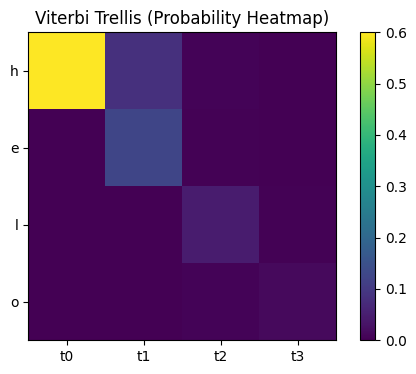

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.imshow(viterbi)
plt.xticks(range(T), [f"t{t}" for t in range(T)])
plt.yticks(range(N), states)
plt.title("Viterbi Trellis (Probability Heatmap)")
plt.colorbar()
plt.show()


The first state (h at t0) is bright yellow because it has the highest probability (0.6). As the Viterbi algorithm multiplies transition and emission probabilities across time, later values become much smaller, so they appear darker on the heatmap.

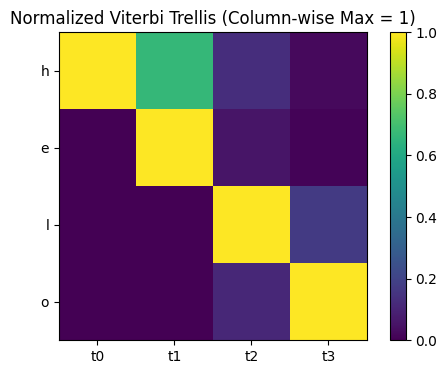

In [6]:
import numpy as np
import matplotlib.pyplot as plt


viterbi_norm = viterbi / viterbi.max(axis=0, keepdims=True)

plt.figure(figsize=(6,4))
plt.imshow(viterbi_norm)
plt.xticks(range(T), [f"t{t}" for t in range(T)])
plt.yticks(range(N), states)
plt.title("Normalized Viterbi Trellis (Column-wise Max = 1)")
plt.colorbar()
plt.show()



# **What Have We Done?**

We **scaled each column** of the Viterbi probability table so that:

###  The highest probability in *each time step* becomes **1 (yellow)**

and all other values in that column are scaled relative to it.

This is called **column-wise normalization**.

It does **not** change the Viterbi result —
it only makes the visual explanation clearer.

---

# **What Is Visible?**

The heatmap now clearly shows:

* **t0** → brightest = **h**
* **t1** → brightest = **e**
* **t2** → brightest = **l**
* **t3** → brightest = **o**

Every column shows **exactly one yellow cell** →
the most likely phoneme at that time.

All other cells appear darker, meaning they had lower probabilities.

---

#  **What Does It Mean?**

This visualization reveals the **phoneme chosen at each step** by the Viterbi algorithm in a very clear way.



* At time **t0**, the model is most confident about **/h/**
* At **t1**, it shifts confidence to **/e/**
* At **t2**, the strongest state becomes **/l/**
* At **t3**, the winner is **/o/**

### So the decoded phoneme sequence is:

**h → e → l → o**

This normalized plot makes it obvious visually,
even without looking at the actual numbers.

---

# **Why Was Normalization Needed?**

In the original heatmap:

* The first value (0.6) was MUCH larger than all later values
* So only one square looked bright
* Later values were all tiny → all dark purple
* Hard to visually understand the progression through states

By normalizing:

* Each time-step gets its own “brightness scale”
* The **most likely state becomes visible** in every column
* The Viterbi path becomes visually clear

---



> “Column-wise normalization highlights the most likely phoneme at each time-step, making the Viterbi decoding path (h → e → l → o) visually clear and easy to interpret.”




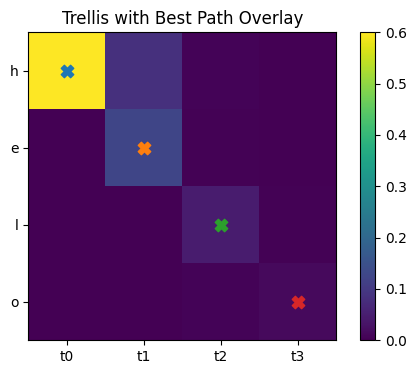

In [3]:
best_path = [states.index(s) for s in decoded_states]  # convert path to indices

plt.figure(figsize=(6,4))
plt.imshow(viterbi)
plt.xticks(range(T), [f"t{t}" for t in range(T)])
plt.yticks(range(N), states)
plt.title("Trellis with Best Path Overlay")
plt.colorbar()

# Overlay points of best path
for t, s in enumerate(best_path):
    plt.scatter(t, s, s=80, marker="X")  # X marks the chosen state

plt.show()


# **What do we see?**

The same trellis heatmap, but with colorful X marks showing the actual path chosen by the Viterbi algorithm.

X at h (t0)

X at e (t1)

X at l (t2)

X at o (t3)

# **Why is this important?**

This makes the Viterbi output visually obvious:

It highlights exactly which state was selected at each time.

It is the visual explanation of the “most likely sequence”.

# **What does it mean?**

This is the final decoded phoneme sequence.

/h/ → /e/ → /l/ → /o/

The X marks show how Viterbi found the most likely pronunciation of the observation sequence.

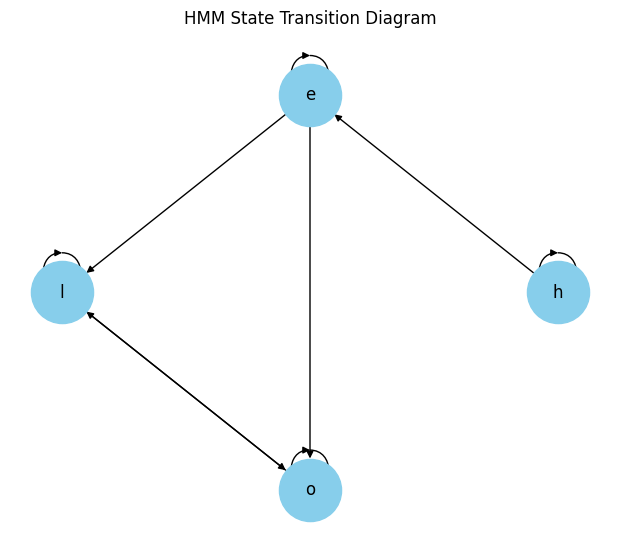

In [4]:
import networkx as nx

G = nx.DiGraph()

# Add states
for s in states:
    G.add_node(s)

# Add edges according to A matrix (non-zero probs)
for i, s_from in enumerate(states):
    for j, s_to in enumerate(states):
        if A[i][j] > 0:
            G.add_edge(s_from, s_to)

plt.figure(figsize=(6,5))
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=2000, arrows=True)
plt.title("HMM State Transition Diagram")
plt.show()


# **What do we see?**

A graph showing how the model believes phonemes can transition:

h → e → l → o


and loops where allowed (if transition probability > 0).

# **Why does it look like this?**

Because transition matrix A encodes these transitions as the correct structure for the simplified “hello” HMM.

The diagram helps visualize:

- Allowed paths

- Direction of progression

- Order of phonemes

# **What does it mean?**

The graph represents the model’s internal structure.
It explains why the Viterbi path must follow a valid sequence:

→ You cannot jump from h → o directly
→ You cannot go backward
→ You cannot repeat l twice (model has only one L state)

It visually confirms the model will produce “h-e-l-o”.



transitions allowed according to A

From h:

h → h (0.7)

h → e (0.3)

From e:

e → e (0.2)

e → l (0.6)

e → o (0.2) (this is why we see an arrow from e → o)

From l:

l → l (0.3) (self-loop)

l → o (0.7)

From o:

o → l (0.1) (that means backward transition allowed)

o → o (0.9)

                ┌────────────────────────────────────┐
                │          START VITERBI             │
                └────────────────────────────────────┘
                             │
                             ▼
     ┌────────────────────────────────────────────────────────┐
     │  INPUTS:                                                │
     │  • States S = {h, e, l, o}                              │
     │  • Observations O = {O1, O2, O3, O4}                    │
     │  • Transition matrix A                                  │
     │  • Emission matrix B                                    │
     │  • Initial probs π                                      │
     │  • Observation sequence = [O1, O2, O3, O4]              │
     └────────────────────────────────────────────────────────┘
                             │
                             ▼
         ┌────────────────────────────────────────┐
         │   INITIALIZATION (t = 0)               │
         │   For each state s:                    │
         │   v[s,0] = π[s] × B[s, O1]             │
         │   backpointer[s,0] = 0                 │
         └────────────────────────────────────────┘
                             │
                             ▼
        ┌──────────────────────────────────────────┐
        │      RECURSION (t = 1 to T-1)            │
        │   For each time t and each state s:      │
        │   1. Compute:                            │
        │      v_prev = v[all_states, t−1] × A     │
        │   2. Choose state with max v_prev        │
        │   3. Update: v[s,t] = max × B[s, Ot]     │
        │   4. Store backpointer                   │
        └──────────────────────────────────────────┘
                             │
                             ▼
               ┌─────────────────────────────────┐
               │        TERMINATION               │
               │   Best final state = argmax v[s,T]│
               └─────────────────────────────────┘
                             │
                             ▼
             ┌───────────────────────────────────────┐
             │         BACKTRACKING (Trace Path)      │
             │  Starting from best final state:        │
             │  Follow backpointers from t=T → 0       │
             │  Retrieve most likely phoneme path      │
             └───────────────────────────────────────┘
                             │
                             ▼
         ┌──────────────────────────────────────────────┐
         │ OUTPUT:                                       │
         │ • Most likely phoneme sequence: h → e → l → o │
         │ • Probability of best path                    │
         └──────────────────────────────────────────────┘
                             │
                             ▼
                ┌──────────────────────────────────┐
                │               END                 │
                └──────────────────────────────────┘
